In [180]:
import time
import numpy as np
import os
import pandas as pd
from collections import defaultdict
from PIL import Image, ImageDraw, ImageFont
from moviepy import ImageClip, CompositeVideoClip, AudioFileClip, ColorClip, VideoFileClip

from edge_tts import list_voices, Communicate
from pydub import AudioSegment

pd.options.display.max_columns = 100
pd.options.display.max_rows = 130

# 0. Settings

In [35]:
data_settings = {
    'category': '交通标志',
    'output_path_base': 'output/anomia_shorts/'
}
data_settings['output_path'] = os.path.join(
    data_settings['output_path_base'],
    data_settings['category'].replace(' ', '_')
)
data_settings['output_path_audio'] = os.path.join(
    data_settings['output_path'],
    'audio_files'
)
data_settings['output_path_images'] = os.path.join(
    data_settings['output_path'],
    'images'
)

# Get category index, pinyin, english from data
df_categories = pd.read_csv('static/texts/lists/anomia_categories.csv')
this_category = df_categories[df_categories['chinese'] == data_settings['category']].iloc[0]
data_settings['category_pinyin'] = this_category['pinyin']
data_settings['category_english'] = this_category['english']
data_settings['category_id'] = this_category['id']
data_settings

{'category': '交通标志',
 'output_path_base': 'output/anomia_shorts/',
 'output_path': 'output/anomia_shorts/交通标志',
 'output_path_audio': 'output/anomia_shorts/交通标志/audio_files',
 'output_path_images': 'output/anomia_shorts/交通标志/images',
 'category_pinyin': 'jiāo tōng biāo zhì',
 'category_english': 'traffic signs',
 'category_id': np.int64(1)}

In [15]:
audio_settings = {
    'voice_name_zh': 'zh-CN-XiaoxiaoNeural',
    'audio_plan': 'ctitle_c2word',
    'pause_ms_beginning': 150,
    'pause_ms_within_word': 200,
    'pause_ms_between': 500,
}
audio_settings

{'voice_name_zh': 'zh-CN-XiaoxiaoNeural',
 'audio_plan': 'ctitle_c2word',
 'pause_ms_beginning': 150,
 'pause_ms_within_word': 200,
 'pause_ms_between': 500}

In [ ]:
BG_SIZE = (720, 1280)
video_configs = {
    'bg_size': BG_SIZE,
    'bg_color': 'white',
    'text_color': 'black',

    'max_line_length_buffer_size': 60,
    'decrease_font_step_size': 1,
    'font_path': '/System/Library/Fonts/STHeiti Medium.ttc',

    'title_settings': {
        'x': 30,
        'y': 30,
        'spacing': 30,
        'align': 'center',
        'font_size': 50,
        'fill': {'chinese': '#FFFFFF', 'pinyin': '#CCCCCC', 'english': '#CCCCCC'},
    },

    'words_settings': {
        'x': {'chinese': '30', 'pinyin': '200', 'english': '400'},
        'y': 200,
        'spacing': 30,
        'font_size': 36,
        'align': {'chinese': 'left', 'pinyin': 'left', 'english': 'left'},
        'fill': {'chinese': '#FFFFFF', 'pinyin': '#CCCCCC', 'english': '#CCCCCC'},
    },

    'horizontal_line': {
        'x': 10,
        'y': 140,
        'color': "#1E90FF",
        'width': 4,
    },

    'logo': {
        'font_name': 'Arial Black',
        'font_size': 20,
        'x': 50,
        'y': 50,
        'color1': "#3E78D6",
        'color2': "#2FDDFC",
    },

    'category_index': {
        'index_value': 1,
        'index_total': 100,
        'font_name': 'Arial Black',
        'font_size': 36,
        'x': BG_SIZE[0] - 30 - 100,
        'y': 50,
        'color1': "#FFFFFF",
        'color2': "#CCCCCC",
    },
}
video_configs

{'bg_size': (720, 1280),
 'bg_color': 'white',
 'text_color': 'black',
 'max_line_length_buffer_size': 60,
 'decrease_font_step_size': 1,
 'font_path': '/System/Library/Fonts/STHeiti Medium.ttc',
 'title_settings': {'x': 30,
  'y': 30,
  'spacing': 30,
  'align': 'center',
  'font_size': 50,
  'fill': {'chinese': '#FFFFFF', 'pinyin': '#CCCCCC', 'english': '#CCCCCC'}},
 'words_settings': {'x': {'chinese': '30', 'pinyin': '200', 'english': '400'},
  'y': 200,
  'spacing': 30,
  'font_size': 36,
  'align': {'chinese': 'left', 'pinyin': 'left', 'english': 'left'},
  'fill': {'chinese': '#FFFFFF', 'pinyin': '#CCCCCC', 'english': '#CCCCCC'}},
 'horizontal_line': {'x': 10, 'y': 140, 'color': '#1E90FF', 'width': 4},
 'logo': {'font_name': 'Arial Black',
  'font_size': 20,
  'x': 50,
  'y': 50,
  'color1': '#3E78D6',
  'color2': '#2FDDFC'},
 'category_index': {'index_value': 1,
  'index_total': 100,
  'font_name': 'Arial Black',
  'font_size': 36,
  'x': 590,
  'y': 50,
  'color1': '#FFFFFF',
 

In [33]:
if not os.path.exists(data_settings['output_path_base']):
    os.mkdir(data_settings['output_path_base'])
if not os.path.exists(data_settings['output_path']):
    os.mkdir(data_settings['output_path'])
if not os.path.exists(data_settings['output_path_audio']):
    os.mkdir(data_settings['output_path_audio'])
if not os.path.exists(data_settings['output_path_images']):
    os.mkdir(data_settings['output_path_images'])

# 1. Load data

In [17]:
df_raw = pd.read_csv('static/texts/lists/anomia_examples.csv')
print(len(df_raw))
df_raw.head()

1850


,id,category,chinese,pinyin,english
0,1,交通标志,停车标志,tíng chē biāo zhì,stop sign
1,2,交通标志,限速标志,xiàn sù biāo zhì,speed limit sign
2,3,交通标志,禁止通行,jìn zhǐ tōng xíng,no entry
3,4,交通标志,人行横道,rén xíng héng dào,pedestrian crossing
4,5,交通标志,注意行人,zhù yì xíng rén,watch for pedestrians


In [18]:
# Print for creating audio
df_filt = df_raw[df_raw['category'] == data_settings['category']].reset_index(drop=True)
example_words = df_filt['chinese'].values
example_words

array(['停车标志', '限速标志', '禁止通行', '人行横道', '注意行人', '红绿灯', '单行道', '让行', '学校区域',
       '禁止鸣笛'], dtype=object)

# 2. Generate spoken audio

In [19]:
# import pandas as pd
# from collections import defaultdict
# import os
# import time
# import numpy as np
# import shutil
# import datetime

# from edge_tts import list_voices, Communicate

# voice_name = 'zh-CN-XiaoxiaoNeural'
# category = '交通标志'
# examples = ['停车标志', '限速标志', '禁止通行', '人行横道', '注意行人', '红绿灯', '单行道', '让行', '学校区域',
#        '禁止鸣笛']

# if not os.path.exists(category):
#     os.mkdir(category)


# def single_tts_call(text, voice_name, output_file_name):
#   communicate = Communicate(text, voice_name)
#   communicate.save_sync(output_file_name)

# start_time = time.time()
# for text_str in [category] + examples:
#   print(time.time()-start_time, text_str)
#   single_tts_call(text_str, voice_name, f'{category}/{text_str}.mp3')

# current_datetime = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
# shutil.make_archive(f"{category}_{current_datetime}", 'zip', category)


# 3. Stitch audio together to final audio

In [ ]:
dict_audio_durations = defaultdict(list)
if audio_settings['audio_plan'] == 'ctitle_c2word':
    current_start_time = 0

    # beginning pause
    pause_beginning = AudioSegment.silent(duration=audio_settings['pause_ms_beginning'])
    combined = pause_beginning
    dict_audio_durations['audio_path'].append('pause_beginning')
    dict_audio_durations['duration'].append(audio_settings['pause_ms_beginning'] / 1000)
    dict_audio_durations['start_time'].append(current_start_time)
    current_start_time += audio_settings['pause_ms_beginning'] / 1000
    dict_audio_durations['end_time'].append(current_start_time)

    # title
    title_audio_path = f"{data_settings['output_path_audio']}/{data_settings['category']}.mp3"
    audio = AudioSegment.from_mp3(title_audio_path)
    combined += audio
    dict_audio_durations['audio_path'].append(title_audio_path)
    dict_audio_durations['duration'].append(audio.duration_seconds)
    dict_audio_durations['start_time'].append(current_start_time)
    current_start_time += audio.duration_seconds
    dict_audio_durations['end_time'].append(current_start_time)

    # words
    for i_word, word in enumerate(example_words):
        # inter-word pause
        pause_inter_word = AudioSegment.silent(duration=audio_settings['pause_ms_between'])
        combined += pause_inter_word
        dict_audio_durations['audio_path'].append('inter_word_pause')
        dict_audio_durations['duration'].append(audio_settings['pause_ms_between'] / 1000)
        dict_audio_durations['start_time'].append(current_start_time)
        current_start_time += audio_settings['pause_ms_between'] / 1000
        dict_audio_durations['end_time'].append(current_start_time)
        
        # word audio
        word_audio_path = f"{data_settings['output_path_audio']}/{word}.mp3"
        audio = AudioSegment.from_mp3(word_audio_path)
        combined += audio 
        dict_audio_durations['audio_path'].append(word_audio_path)
        dict_audio_durations['duration'].append(audio.duration_seconds)
        dict_audio_durations['start_time'].append(current_start_time)
        current_start_time += audio.duration_seconds
        dict_audio_durations['end_time'].append(current_start_time)

        # within-word pause
        pause_within_word = AudioSegment.silent(duration=audio_settings['pause_ms_within_word'])
        combined += pause_within_word
        dict_audio_durations['audio_path'].append('within_word_pause')
        dict_audio_durations['duration'].append(audio_settings['pause_ms_within_word'] / 1000)
        dict_audio_durations['start_time'].append(current_start_time)
        current_start_time += audio_settings['pause_ms_within_word'] / 1000
        dict_audio_durations['end_time'].append(current_start_time)

        # word again audio
        combined += audio 
        dict_audio_durations['audio_path'].append(word_audio_path)
        dict_audio_durations['duration'].append(audio.duration_seconds)
        dict_audio_durations['start_time'].append(current_start_time)
        current_start_time += audio.duration_seconds
        dict_audio_durations['end_time'].append(current_start_time)

# export the combined audio file
combined.export(f"{data_settings['output_path_audio']}/combined.mp3", format="mp3")
print(f'Audio duration: {combined.duration_seconds:.1f}s')

# Add in static slide audio into dataframe of audio durations
df_durations = pd.DataFrame(dict_audio_durations)
df_durations.head(10)


Audio duration: 40.2


,audio_path,duration,start_time,end_time
0,pause_beginning,0.150,0.000,0.150
1,output/anomia_shorts/交通标志/audio_files/交通标志.mp3,1.680,0.150,1.830
2,inter_word_pause,0.500,1.830,2.330
3,output/anomia_shorts/交通标志/audio_files/停车标志.mp3,1.656,2.330,3.986
4,within_word_pause,0.200,3.986,4.186
5,output/anomia_shorts/交通标志/audio_files/停车标志.mp3,1.656,4.186,5.842
6,inter_word_pause,0.500,5.842,6.342
7,output/anomia_shorts/交通标志/audio_files/限速标志.mp3,1.704,6.342,8.046
8,within_word_pause,0.200,8.046,8.246
9,output/anomia_shorts/交通标志/audio_files/限速标志.mp3,1.704,8.246,9.950


In [8]:
df_durations.tail(10)

,audio_path,duration,start_time,end_time
32,within_word_pause,0.200,30.678,30.878
33,output/anomia_shorts/交通标志/audio_files/让行.mp3,1.368,30.878,32.246
34,inter_word_pause,0.500,32.246,32.746
35,output/anomia_shorts/交通标志/audio_files/学校区域.mp3,1.680,32.746,34.426
36,within_word_pause,0.200,34.426,34.626
37,output/anomia_shorts/交通标志/audio_files/学校区域.mp3,1.680,34.626,36.306
38,inter_word_pause,0.500,36.306,36.806
39,output/anomia_shorts/交通标志/audio_files/禁止鸣笛.mp3,1.608,36.806,38.414
40,within_word_pause,0.200,38.414,38.614
41,output/anomia_shorts/交通标志/audio_files/禁止鸣笛.mp3,1.608,38.614,40.222


# 4. Create main image

In [25]:
from utils_video import (
    determine_if_text_size_too_big
)

In [130]:
def draw_resized_text_on_image(draw, text_settings, is_centered=False):
    font = ImageFont.truetype(text_settings['font_path'], text_settings['font_size'])
    new_font_size = text_settings['font_size']
    font_size_too_big = determine_if_text_size_too_big(text_settings['text'], font, line_length=text_settings['max_line_length'])
    while font_size_too_big:
        if new_font_size <= 5:
            text_settings['text'] = text_settings['text'][:-1]
            print(f'reduced text to {text_settings['text']}')
        else:
            new_font_size -= video_configs['decrease_font_step_size']
            print(f'reduced font size to {new_font_size}')
        font = ImageFont.truetype(text_settings['font_path'], new_font_size)
        font_size_too_big = determine_if_text_size_too_big(text_settings['text'], font, line_length=text_settings['max_line_length'])

    # Get longest line length
    longest_length = max([font.getlength(x) for x in text_settings['text'].split('\n')])
    if is_centered:
        text_settings['x'] = video_configs['bg_size'][0] / 2 - longest_length / 2
    draw.multiline_text(
        xy=(text_settings['x'], text_settings['y'])
        , text=text_settings['text'], font=font
        , fill=text_settings['fill'], spacing=text_settings['spacing'], align=text_settings['align']
        )

In [106]:
def draw_logo(draw, video_configs):
    logo_font = ImageFont.truetype(video_configs['logo']['font_name'], video_configs['logo']['font_size'])
    draw.text(
        xy=(video_configs['logo']['x'] - logo_font.getlength('My'), video_configs['logo']['y']),
        text='My',
        font=logo_font,
        fill=video_configs['logo']['color1'],
        align='right'
        )
    draw.text(
        xy=(video_configs['logo']['x'] - logo_font.getlength('Mandarin'), video_configs['logo']['y'] + video_configs['logo']['font_size']),
        text='Mandarin',
        font=logo_font,
        fill=video_configs['logo']['color2'],
        align='right'
        )
    draw.text(
        xy=(video_configs['logo']['x'] - logo_font.getlength('Database'), video_configs['logo']['y'] + 2*video_configs['logo']['font_size']),
        text='Database',
        font=logo_font,
        fill=video_configs['logo']['color1'],
        align='right'
        )

In [163]:
def draw_word_index(draw, video_configs, n_vocab, word_idx):
    word_index_font = ImageFont.truetype(video_configs['category_index']['font_name'], video_configs['category_index']['font_size'])
    word_index_part2_length = word_index_font.getlength(f"/{n_vocab}")
    word_index_length = word_index_font.getlength(f"{word_idx+1}/{n_vocab}")
    draw.text(
        text=f"/{n_vocab}",
        xy=(
            video_configs['category_index']['x'] - word_index_part2_length,
            video_configs['category_index']['y']
            ),
        font=word_index_font,
        fill=video_configs['category_index']['color2'],
        align='left'
    )
    draw.text(
        text=f"{word_idx}",
        xy=(
            video_configs['category_index']['x'] - word_index_length - 2,
            video_configs['category_index']['y']
            ),
        font=word_index_font,
        fill=video_configs['category_index']['color1'],
        align='left'
    )



In [170]:
BG_SIZE = (720, 1280)
video_configs = {
    'bg_size': BG_SIZE,
    'bg_color': 'white',
    'text_color': 'black',

    'max_line_length': BG_SIZE[0] - 160,
    'decrease_font_step_size': 1,
    'font_path': '/System/Library/Fonts/STHeiti Medium.ttc',

    'title_settings': {
        'x': 50,
        'y': 50,
        'spacing': 18,
        'align': 'center',
        'font_size': {'chinese': 70, 'pinyin': 50, 'english': 50},
        'fill': {'chinese': '#000000', 'pinyin': '#222222', 'english': '#222222'},
    },

    'words_settings': {
        'x': {'chinese': 30, 'pinyin': 180, 'english': 450},
        'max_line_length_buffer_size': {'chinese': 30, 'pinyin': 30, 'english': 30},
        'max_line_length': {},
        'y_gap': 50,
        'spacing': 50,
        'font_size': {'chinese': 32, 'pinyin': 32, 'english': 32},
        'align': {'chinese': 'left', 'pinyin': 'left', 'english': 'left'},
        'fill': {'chinese': '#000000', 'pinyin': '#000000', 'english': '#000000'},
    },

    'horizontal_line': {
        'y_gap': 40,
        'x': 10,
        'color': "#1E90FF",
        'width': 10,
    },

    'bottom_line': {
        'y_gap': 28,
        'x': 10,
        'color': "#1E90FF",
        'width': 10,
    },

    'logo': {
        'font_name': 'Arial Black',
        'font_size': 20,
        'x': BG_SIZE[0] - 30,
        'y': 1200,
        'color1': "#3E78D6",
        'color2': "#2FDDFC",
    },

    'category_index': {
        'index_value': 1,
        'index_total': 100,
        'font_name': 'Arial Black',
        'font_size': 48,
        'x': 170,
        'y': 1200,
        'color1': "#000000",
        'color2': "#777777",
    },
}
video_configs['horizontal_line']['y'] = video_configs['title_settings']['y'] + \
    video_configs['title_settings']['font_size']['chinese']+ \
    video_configs['title_settings']['font_size']['pinyin'] + \
    video_configs['title_settings']['font_size']['english'] + \
    video_configs['horizontal_line']['y_gap'] + \
    2*video_configs['title_settings']['spacing']

video_configs['bottom_line']['y'] = video_configs['category_index']['y'] - \
    video_configs['bottom_line']['y_gap']

video_configs['words_settings']['y'] = video_configs['horizontal_line']['y'] + \
    video_configs['words_settings']['y_gap']
video_configs['words_settings']['max_line_length']['chinese'] = video_configs['words_settings']['x']['pinyin'] - video_configs['words_settings']['x']['chinese'] - video_configs['words_settings']['max_line_length_buffer_size']['chinese']
video_configs['words_settings']['max_line_length']['pinyin'] = video_configs['words_settings']['x']['english'] - video_configs['words_settings']['x']['pinyin'] - video_configs['words_settings']['max_line_length_buffer_size']['pinyin']
video_configs['words_settings']['max_line_length']['english'] = BG_SIZE[0] - video_configs['words_settings']['x']['english'] - video_configs['words_settings']['max_line_length_buffer_size']['english']

{'text': '停车标志', 'font_path': '/System/Library/Fonts/STHeiti Medium.ttc', 'font_size': 32, 'x': 30, 'y': 346, 'spacing': 50, 'align': 'left', 'fill': '#000000', 'max_line_length': 120}
reduced font size to 31
reduced font size to 30
reduced font size to 31
reduced font size to 30
{'text': '限速标志', 'font_path': '/System/Library/Fonts/STHeiti Medium.ttc', 'font_size': 32, 'x': 30, 'y': 428, 'spacing': 50, 'align': 'left', 'fill': '#000000', 'max_line_length': 120}
reduced font size to 31
reduced font size to 30
{'text': '禁止通行', 'font_path': '/System/Library/Fonts/STHeiti Medium.ttc', 'font_size': 32, 'x': 30, 'y': 510, 'spacing': 50, 'align': 'left', 'fill': '#000000', 'max_line_length': 120}
reduced font size to 31
reduced font size to 30
{'text': '人行横道', 'font_path': '/System/Library/Fonts/STHeiti Medium.ttc', 'font_size': 32, 'x': 30, 'y': 592, 'spacing': 50, 'align': 'left', 'fill': '#000000', 'max_line_length': 120}
reduced font size to 31
reduced font size to 30
reduced font size to


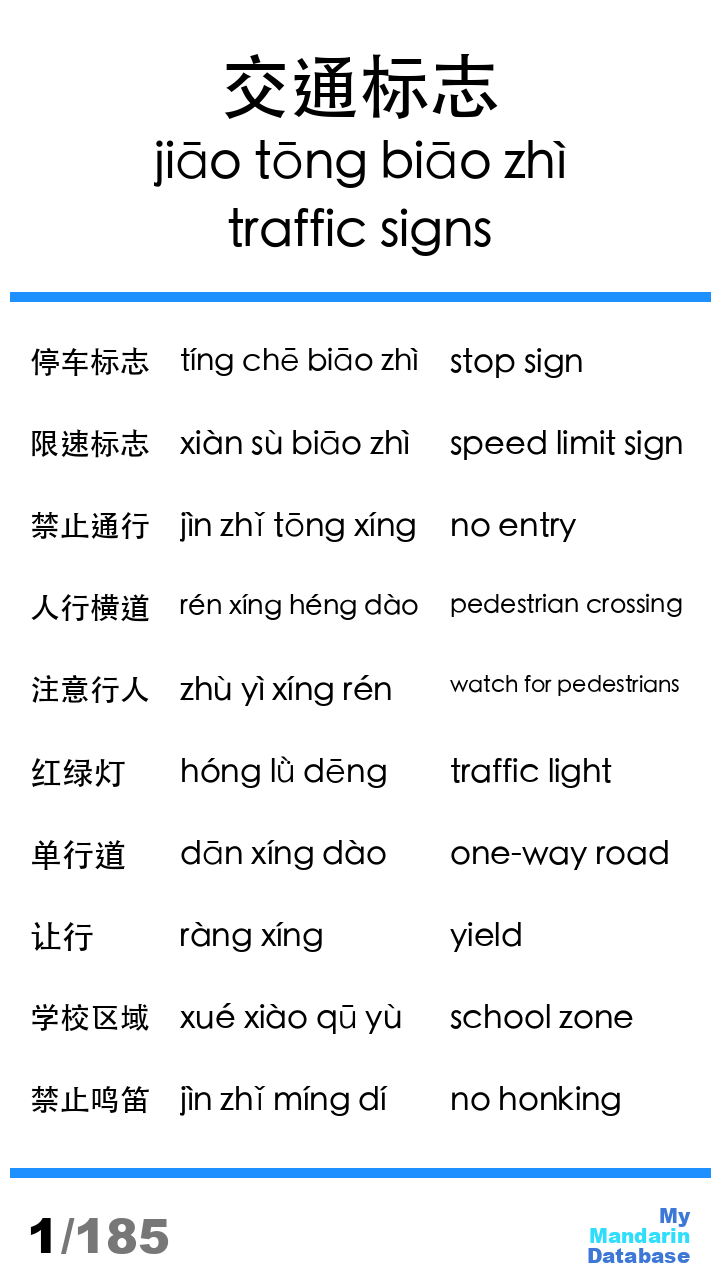

In [172]:
original_img = Image.new("RGB", BG_SIZE, color=video_configs['bg_color'])
draw = ImageDraw.Draw(original_img)

# 1. Logo
draw_logo(draw, video_configs)

# 2. Index
draw_word_index(draw, video_configs, len(df_categories), data_settings['category_id'])

# 3. Title
title_text_settings = {}
title_text_settings['chinese'] = {
    'text': data_settings['category'],
    'font_path': video_configs['font_path'],
    'font_size': video_configs['title_settings']['font_size']['chinese'],
    'y': video_configs['title_settings']['y'],
    'spacing': video_configs['title_settings']['spacing'],
    'align': video_configs['title_settings']['align'],
    'fill': video_configs['title_settings']['fill']['chinese'],
    'max_line_length': video_configs['max_line_length'],
}
title_text_settings['pinyin'] = {
    'text': data_settings['category_pinyin'],
    'font_path': video_configs['font_path'],
    'font_size': video_configs['title_settings']['font_size']['pinyin'],
    'y': video_configs['title_settings']['y'] + video_configs['title_settings']['font_size']['chinese'] + video_configs['title_settings']['spacing'],
    'spacing': video_configs['title_settings']['spacing'],
    'align': video_configs['title_settings']['align'],
    'fill': video_configs['title_settings']['fill']['chinese'],
    'max_line_length': video_configs['max_line_length'],
}
title_text_settings['english'] = {
    'text': data_settings['category_english'],
    'font_path': video_configs['font_path'],
    'font_size': video_configs['title_settings']['font_size']['english'],
    'y': video_configs['title_settings']['y'] + video_configs['title_settings']['font_size']['chinese'] + video_configs['title_settings']['font_size']['pinyin'] + 2*video_configs['title_settings']['spacing'],
    'spacing': video_configs['title_settings']['spacing'],
    'align': video_configs['title_settings']['align'],
    'fill': video_configs['title_settings']['fill']['chinese'],
    'max_line_length': video_configs['max_line_length'],
}
draw_resized_text_on_image(draw, title_text_settings['chinese'], is_centered=True)
draw_resized_text_on_image(draw, title_text_settings['pinyin'], is_centered=True)
draw_resized_text_on_image(draw, title_text_settings['english'], is_centered=True)

# 4. Horizontal line
draw.line([
    (video_configs['horizontal_line']['x'], video_configs['horizontal_line']['y']),
    (video_configs['bg_size'][0] - video_configs['horizontal_line']['x'], video_configs['horizontal_line']['y'])],
    fill=video_configs['horizontal_line']['color'],
    width=video_configs['horizontal_line']['width'],
    joint=None)
draw.line([
    (video_configs['bottom_line']['x'], video_configs['bottom_line']['y']),
    (video_configs['bg_size'][0] - video_configs['bottom_line']['x'], video_configs['bottom_line']['y'])],
    fill=video_configs['bottom_line']['color'],
    width=video_configs['bottom_line']['width'],
    joint=None)

# 5. Words
for i_row, row in df_filt.iterrows():
    # Chinese
    text_settings = {
        'text': row['chinese'],
        'font_path': video_configs['font_path'],
        'font_size': video_configs['words_settings']['font_size']['chinese'],
        'x': video_configs['words_settings']['x']['chinese'],
        'y': video_configs['words_settings']['y'] + i_row * (video_configs['words_settings']['font_size']['chinese'] + video_configs['words_settings']['spacing']),
        'spacing': video_configs['words_settings']['spacing'],
        'align': video_configs['words_settings']['align']['chinese'],
        'fill': video_configs['words_settings']['fill']['chinese'],
        'max_line_length': video_configs['words_settings']['max_line_length']['chinese'],
    }
    print(text_settings)
    draw_resized_text_on_image(draw, text_settings)

    # Pinyin
    text_settings = {
        'text': row['pinyin'],
        'font_path': video_configs['font_path'],
        'font_size': video_configs['words_settings']['font_size']['pinyin'],
        'x': video_configs['words_settings']['x']['pinyin'],
        'y': video_configs['words_settings']['y'] + i_row * (video_configs['words_settings']['font_size']['chinese'] + video_configs['words_settings']['spacing']),
        'spacing': video_configs['words_settings']['spacing'],
        'align': video_configs['words_settings']['align']['pinyin'],
        'fill': video_configs['words_settings']['fill']['pinyin'],
        'max_line_length': video_configs['words_settings']['max_line_length']['pinyin'],
    }
    draw_resized_text_on_image(draw, text_settings)

    # English
    text_settings = {
        'text': row['english'],
        'font_path': video_configs['font_path'],
        'font_size': video_configs['words_settings']['font_size']['english'],
        'x': video_configs['words_settings']['x']['english'],
        'y': video_configs['words_settings']['y'] + i_row * (video_configs['words_settings']['font_size']['chinese'] + video_configs['words_settings']['spacing']),
        'spacing': video_configs['words_settings']['spacing'],
        'align': video_configs['words_settings']['align']['english'],
        'fill': video_configs['words_settings']['fill']['english'],
        'max_line_length': video_configs['words_settings']['max_line_length']['english'],
    }
    draw_resized_text_on_image(draw, text_settings)

no_hl_img_file_path = f"{data_settings['output_path_images']}/no_highlights.png"
original_img.save(no_hl_img_file_path)
my_img = ImageClip(no_hl_img_file_path, duration=1).with_start(0)
my_img.display_in_notebook()

# 5. Create video without highlights

In [ ]:
combined_audio = AudioFileClip(f"{data_settings['output_path_audio']}/combined.mp3")
clips_no_highlights = [ImageClip(no_hl_img_file_path, duration=combined_audio.duration).with_start(0)]
video = CompositeVideoClip(clips_no_highlights, size=BG_SIZE)
video.audio = combined_audio
video.duration = combined_audio.duration
no_highlights_video_path = f"{data_settings['output_path']}/{data_settings['category']}_no_highlights.mp4"
video.write_videofile(no_highlights_video_path, fps=24)

                                                                        
                                                                         
frame_index:   0%|          | 2/966 [01:31<12:14:36, 45.72s/it, now=None]

MoviePy - Building video output/anomia_shorts/交通标志/交通标志_no_highlights.mp4.
MoviePy - Writing audio in 交通标志_no_highlightsTEMP_MPY_wvf_snd.mp3





                                                                         
                                                                         
frame_index:   0%|          | 2/966 [01:31<12:15:54, 45.80s/it, now=None]

MoviePy - Done.
MoviePy - Writing video output/anomia_shorts/交通标志/交通标志_no_highlights.mp4


































































































































































                                                                         
                                                                         
frame_index:   0%|          | 2/966 [01:49<14:36:11, 54.53s/it, now=None]

MoviePy - Done !
MoviePy - video ready output/anomia_shorts/交通标志/交通标志_no_highlights.mp4


# 6. Create video with word highlights

In [ ]:
# Compute highlight durations
highlight_start_ids = np.arange(3,42,4)
highlight_end_ids = np.arange(5,42,4)
dict_highlight_durations = defaultdict(list)
for i_row, row in df_durations.iterrows():
    if i_row in highlight_start_ids:
        dict_highlight_durations['start_time'].append(row['start_time'] - audio_settings['pause_ms_within_word']/(2*1000))
    if i_row in highlight_end_ids:
        dict_highlight_durations['end_time'].append(row['end_time'] + audio_settings['pause_ms_within_word']/(2*1000))
df_highlight_durations = pd.DataFrame(dict_highlight_durations)
df_highlight_durations['duration'] = df_highlight_durations['end_time'] - df_highlight_durations['start_time']
df_highlight_durations

,start_time,end_time,duration
0,2.230,5.942,3.712
1,6.242,10.050,3.808
2,10.350,14.062,3.712
3,14.362,18.122,3.760
4,18.422,21.846,3.424
5,22.146,25.330,3.184
6,25.630,28.910,3.280
7,29.210,32.346,3.136
8,32.646,36.406,3.760
9,36.706,40.322,3.616


In [199]:
no_highlights_video_path = f"{data_settings['output_path']}/{data_settings['category']}_no_highlights.mp4"
video = VideoFileClip(no_highlights_video_path)
clips_with_highlights = [video]

rect_x_buffer = 8
rect_width = BG_SIZE[0] - 2*video_configs['words_settings']['max_line_length_buffer_size']['english'] + 2*rect_x_buffer
rect_height = video_configs['words_settings']['font_size']['chinese'] + video_configs['words_settings']['spacing']
rect_x = video_configs['words_settings']['max_line_length_buffer_size']['english'] - rect_x_buffer
for i_row, row in df_highlight_durations.iterrows():
    rect_y = video_configs['words_settings']['y'] - \
        (video_configs['words_settings']['spacing']/2) + \
        i_row*(video_configs['words_settings']['spacing'] + video_configs['words_settings']['font_size']['chinese'])
    rect = (ColorClip(size=(rect_width, rect_height), color=[0, 255, 0], duration=row['duration'])
            .with_start(row['start_time'])
            .with_opacity(0.5)
            .with_position((rect_x, rect_y)))
    clips_with_highlights.append(rect)

# Overlay the rectangle on the video
final_video = CompositeVideoClip(clips_with_highlights)
final_video.write_videofile(f"{data_settings['output_path']}/{data_settings['category']}.mp4", codec="libx264")

                                                                           
                                                                     

frame_index:   0%|          | 2/966 [20:49<167:16:23, 624.67s/it, now=None]
                                                                           
                                                                     

frame_index:   0%|          | 2/966 [20:49<167:16:25, 624.67s/it, now=None]


MoviePy - Building video output/anomia_shorts/交通标志/交通标志.mp4.
MoviePy - Writing audio in 交通标志TEMP_MPY_wvf_snd.mp3








                                                                           
                                                                     

frame_index:   0%|          | 2/966 [20:49<167:18:08, 624.78s/it, now=None]
                                                                           
                                                                     

frame_index:   0%|          | 2/966 [20:49<167:18:09, 624.78s/it, now=None]


MoviePy - Done.
MoviePy - Writing video output/anomia_shorts/交通标志/交通标志.mp4





































































































































































































































































































































/Users/scott/Library/Caches/pypoetry/virtualenvs/my-mandarin-database-XyoBA6Fv-py3.13/lib/python3.13/site-packages/moviepy/video/io/ffmpeg_reader.py:190: UserWarning: In file output/anomia_shorts/交通标志/交通标志_no_highlights.mp4, 2764800 bytes wanted but 0 bytes read at frame index 966 (out of a total 966 frames), at time 40.25/40.28 sec. Using the last valid frame instead.
  warnings.warn(


                                                                           
                                                                     

frame_index:   0%|          | 2/966 [21:07<169:42:39, 633.78s/it, now=None]
                                                                

MoviePy - Done !
MoviePy - video ready output/anomia_shorts/交通标志/交通标志.mp4
